# Transdiagnostic Cohen's d map

This notebook calculates the parcel-wise transdiagnostic cohens'd map between patients (SCZ, MDD, and BD) and held-out healthy controls. 


In [1]:
from pathlib import Path
import sys

from IPython.display import display
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import pandas as pd
from scipy.linalg import lstsq
from sklearn.preprocessing import MinMaxScaler


project_root = Path('../..').resolve()
info_dir = project_root / 'data' / 'clinical' / 'info'
rsi_dir = project_root / 'results' / 'rsi' / 'clinical'
font_path = project_root / 'font' / 'Whitney-Medium.otf'

if str(project_root) not in sys.path:
    # Keep installed packages ahead of repository-only analysis helpers.
    sys.path.append(str(project_root))

from analysis.clinical.functions import harmonize_with_combat
from rise.surface_plot import visualize_parcel_surface_map


if font_path.exists():
    fm.fontManager.addfont(font_path)
    plt.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['svg.fonttype'] = 'none'


/localdata/software/anaconda3/envs/rise_env/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load RSI and metadata

In [2]:
def format_subject_ids(values):
    """Return numeric subject identifiers as zero-padded four-character strings."""
    return pd.Index([f'{int(value):04d}' for value in values], name='Subject_ID')


def load_metadata(filename):
    """Load clinical metadata and index rows by normalized subject identifier."""
    metadata = pd.read_csv(info_dir / filename)
    metadata.index = format_subject_ids(metadata['sub_uid'])
    if metadata.index.has_duplicates:
        raise ValueError(f'Duplicate subject identifiers in {filename}')
    return metadata


def load_rsi(filename):
    """Load a parcel-wise RSI table with normalized subject identifiers."""
    rsi = pd.read_csv(rsi_dir / filename, index_col=0)
    rsi.index = format_subject_ids(rsi.index)
    if rsi.index.has_duplicates:
        raise ValueError(f'Duplicate subject identifiers in {filename}')
    return rsi


def build_confounds(metadata, subject_ids):
    """Select and encode ComBat/regression covariates in RSI row order."""
    columns = ['diagnosis', 'PatientSex', 'PatientAge', 'site']
    confounds = metadata.loc[subject_ids, columns].copy()
    confounds['PatientSex'] = confounds['PatientSex'].map({'F': 0, 'M': 1})
    confounds['site'] = confounds['site'].map(
        {'PKU3': 0, 'PKU6': 1, 'PKU6-CP': 2}
    )
    if confounds.isna().any().any():
        missing_columns = confounds.columns[confounds.isna().any()].tolist()
        raise ValueError(f'Unmapped or missing confounds: {missing_columns}')
    return confounds


hc_train_meta = load_metadata('HC_train_meta_info.csv')
hc_test_meta = load_metadata('HC_test_meta_info.csv')
scz_meta = load_metadata('SCZ_meta_info.csv')
mdd_meta = load_metadata('MDD_meta_info.csv')
bd_meta = load_metadata('BD_meta_info.csv')

hc_train_rsi = load_rsi('HC_train_rsi.csv')
hc_test_rsi = load_rsi('HC_test_rsi.csv')
scz_rsi = load_rsi('SCZ_rsi.csv')
mdd_rsi = load_rsi('MDD_rsi.csv')
bd_rsi = load_rsi('BD_rsi.csv')

if not all(table.columns.equals(hc_train_rsi.columns) for table in [hc_test_rsi, scz_rsi, mdd_rsi, bd_rsi]):
    raise ValueError('RSI parcel columns are inconsistent across cohorts')

# Normalize the unit scale using the independent healthy-control training mean.
hc_train_mean_rsi = hc_train_rsi.mean(axis=0)
hc_test_rsi = hc_test_rsi.divide(hc_train_mean_rsi, axis='columns')
scz_rsi = scz_rsi.divide(hc_train_mean_rsi, axis='columns')
mdd_rsi = mdd_rsi.divide(hc_train_mean_rsi, axis='columns')
bd_rsi = bd_rsi.divide(hc_train_mean_rsi, axis='columns')

patient_rsi = pd.concat([scz_rsi, mdd_rsi, bd_rsi], axis=0)
hc_test_confounds = build_confounds(hc_test_meta, hc_test_rsi.index)
patient_confounds = pd.concat(
    [
        build_confounds(scz_meta, scz_rsi.index),
        build_confounds(mdd_meta, mdd_rsi.index),
        build_confounds(bd_meta, bd_rsi.index),
    ],
    axis=0,
)

print(f'Healthy controls: {len(hc_test_rsi)}')
print(f'Patients: {len(patient_rsi)} (SCZ={len(scz_rsi)}, MDD={len(mdd_rsi)}, BD={len(bd_rsi)})')


Healthy controls: 236
Patients: 600 (SCZ=197, MDD=320, BD=83)


## Harmonize sites and regress covariates


In [3]:
def regress_covariates_and_rescale(features, covariates):
    feature_values = np.asarray(features, dtype=float)
    covariate_values = np.asarray(covariates, dtype=float)
    if feature_values.ndim == 1:
        feature_values = feature_values[:, None]
    if covariate_values.ndim == 1:
        covariate_values = covariate_values[:, None]

    design = np.hstack(
        [covariate_values, np.ones((len(covariate_values), 1))]
    )
    adjusted = np.zeros_like(feature_values)

    for parcel_index in range(feature_values.shape[1]):
        parcel_values = feature_values[:, parcel_index]
        coefficients = lstsq(design, parcel_values)[0]
        residuals = parcel_values - covariate_values.dot(coefficients[:-1])

        parcel_min = np.min(parcel_values)
        parcel_max = np.max(parcel_values)
        if parcel_min == parcel_max:
            adjusted[:, parcel_index] = parcel_values
        else:
            adjusted[:, parcel_index] = MinMaxScaler(
                feature_range=(parcel_min, parcel_max)
            ).fit_transform(residuals[:, None]).ravel()

    return adjusted


def residualize_case_control(
    hc_rsi,
    patient_rsi,
    hc_confounds,
    patient_confounds,
    covariate_columns=('PatientAge', 'PatientSex'),
):
    combined_rsi = pd.concat([hc_rsi, patient_rsi], axis=0)
    combined_confounds = pd.concat(
        [
            hc_confounds.loc[:, covariate_columns],
            patient_confounds.loc[:, covariate_columns],
        ],
        axis=0,
    )
    reg_values = regress_covariates_and_rescale(
        combined_rsi.to_numpy(),
        combined_confounds.to_numpy(),
    )
    reg_rsi = pd.DataFrame(
        reg_values,
        index=combined_rsi.index,
        columns=combined_rsi.columns,
    )
    n_hc = len(hc_rsi)
    return reg_rsi.iloc[:n_hc].copy(), reg_rsi.iloc[n_hc:].copy()


combined_rsi = pd.concat([hc_test_rsi, patient_rsi], axis=0)
combined_confounds = pd.concat(
    [hc_test_confounds, patient_confounds], axis=0
)
combined_rsi_combat = harmonize_with_combat(
    features=combined_rsi,
    covariates=combined_confounds,
    batch_col='site',
    discrete_cols=['PatientSex', 'diagnosis'],
    continuous_cols=['PatientAge'],
)

n_hc = len(hc_test_rsi)
hc_test_rsi_combat = combined_rsi_combat.iloc[:n_hc].copy()
patient_rsi_combat = combined_rsi_combat.iloc[n_hc:].copy()

hc_test_rsi_reg, patient_rsi_reg = residualize_case_control(
    hc_test_rsi_combat,
    patient_rsi_combat,
    hc_test_confounds,
    patient_confounds,
)


Creating design matrix..
Standardizing data across features..
Fitting L/S model and finding priors..
Finding parametric adjustments..
Final adjustment of data..


## Calculate the transdiagnostic Cohen's d map.


In [4]:
def mean_center_rows(table):
    """Subtract each subject's mean RSI across parcels."""
    return table.sub(table.mean(axis=1), axis=0)


def cohens_d(group_a, group_b):
    """Calculate parcel-wise Cohen's d using the pooled sample standard deviation."""
    group_a = np.asarray(group_a, dtype=float)
    group_b = np.asarray(group_b, dtype=float)
    n_a, n_b = group_a.shape[0], group_b.shape[0]

    pooled_variance = (
        (n_a - 1) * np.var(group_a, axis=0, ddof=1)
        + (n_b - 1) * np.var(group_b, axis=0, ddof=1)
    ) / (n_a + n_b - 2)
    pooled_sd = np.sqrt(pooled_variance)
    return np.divide(
        np.mean(group_a, axis=0) - np.mean(group_b, axis=0),
        pooled_sd,
        out=np.full_like(pooled_sd, np.nan, dtype=float),
        where=pooled_sd > 0,
    )


hc_test_rsi_centered = mean_center_rows(hc_test_rsi_reg)
patient_rsi_centered = mean_center_rows(patient_rsi_reg)
transdiagnostic_cohens_d = cohens_d(
    patient_rsi_centered,
    hc_test_rsi_centered,
)

## Visualize the map


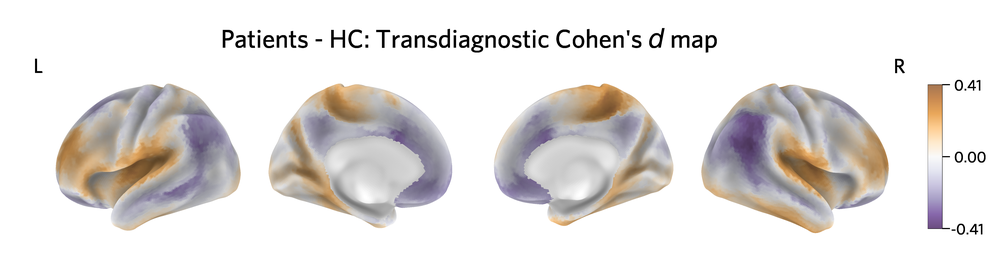

<Figure size 640x480 with 0 Axes>

In [5]:
def brighten_colormap(cmap_name, factor=0.3):
    """Brighten a Matplotlib colormap by interpolating it toward white."""
    if not 0 <= factor <= 1:
        raise ValueError('factor must be between 0 and 1')
    cmap = plt.get_cmap(cmap_name)
    colors = cmap(np.linspace(0, 1, 256))
    brightened_colors = colors * (1 - factor) + np.ones_like(colors) * factor
    return LinearSegmentedColormap.from_list(
        f'{cmap.name}_bright_{factor}',
        brightened_colors,
    )


surface_cmap = brighten_colormap('PuOr_r', factor=0.3)

surface_image = visualize_parcel_surface_map(
    transdiagnostic_cohens_d,
    title="Patients - HC: Transdiagnostic Cohen's $\\it{d}$ map",
    cmap=surface_cmap,
)
display(surface_image)
